# Synthetic DHI generation

## Researching DHI properties

### Soruce: Nanda (2021), *Direct Hydrocarbon Indicators*
https://link.springer.com/chapter/10.1007/978-3-030-75301-6_6

#### Bright spot (gas sand)
- water-saturated sand: ~2300m/s, 2.2g/cm3, producing only a small positive impedance contrast and a weak reflection
- same sand invaded by gas: velocity drops fast to ~1600m/s, density drops slightly to ~2.1g/cm3, this fips the contrast to strong negatoive, it produces the classic **bright, negative polarity reflection**
- this is a before/after contrast ratio I can reproduce as an amplitude boost (instead of choosing random percentage)

#### Flat spot
- moderate to high amplitude, positive polarity, horizontal
- opposite polarity signal to the bright spot above it
- a valid flat spot should sit at the appropriate structural position
    - i.e. if there is one in a syncline (downward u-shaped fold) that is not a hydrocarbon
- good constraint for where to geometrically place my synthetic flat spots 

#### Dim spot
- weak, positive polarity reflection
- in limestone or old sandstone reservoirs

#### Polarity reversal
- a combination signatureL high amplitude + negative polarity that quickly flips to positive polarity down-dip
- marks where gas sand changes to water sand

#### Important about true positives
Bright/flat spots can be produced by volcanics,calcareous streaks, coal beds, overpressured sands, and tuning effects - NOT just hydrocarbons
- polarity is the most useful discriminator, but is hard to determine precisely for thin beds

### Source: Forrest et al. (2010), *Risking seismic amplitude anomaly prospects based on datasets trends*
https://pubs.geoscienceworld.org/seg/tle/article/29/5/570/135930/Risking-seismic-amplitude-anomaly-prospects-based

Less useful for defining what anomaly can look like, more useful for how to tier severity. It says that no single DHI characteristic is reliable alone, but that success rate rise a lot when multiple characteritics exist together. This justifies that I should stack the severity levels in terms of combinations of features, not just scaling one number (for example amplitude percentage) up and down. 

### Source: Roden and Chen (2017), *Interpretation of DHI characteristics with machine learning*
https://www.geoinsights.com/interpretation-of-dhi-characteristics-with-machine-learning/#pdf-11

- Useful for connecting DHI characteristics to attribute (Table 2)
- I.e. I dropped instantaneous phase + frequency from PCA for faces pipeline, but in this paper they are stated as relevant specificallt for DHI detection


## Background Patch Calibration: Dominant Frequency & Tuning Thickness

Before injecting synthetic DHIs, I need a baseline for what "normal" background seismic character looks like on this section — specifically its dominant frequency and the resulting tuning thickness. This matters for severity calibration: Forrest, Roden & Holeywell (2010, cited above) note that no single DHI attribute is reliable in isolation, and one of the things that determines *which* attribute will actually be diagnostic is whether the injected reservoir sits above or below the tuning thickness:
- **Above tuning**: top/base reservoir reflections resolve separately, bed thickness maps roughly linearly onto reflection time separation, and amplitude stays close to the true reflection coefficient.
- **Below tuning**: the two reflections interfere (Widess 1973), amplitude becomes the primary indicator of thickness (via the tuning curve) rather than time separation, and amplitude no longer reflects the true reflection coefficient alone.

So the tuning thickness computed here becomes the reference point for calibrating severity levels later — e.g. "mild" anomalies can sit above tuning where geometry dominates, while "severe" thin-bed anomalies sit below tuning where amplitude dominates.

In [1]:
import pickle
import sys
sys.path.append('..')

import segyio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from utils.seismic_io import read_inline

SEGY_PATH = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_Demo_2023/Rawdata/Seismic_data.sgy'
MASK_PATH = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_interpretation_labels/masks/inline_400_mask.png'
VELOCITY_PATH = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_Demo_2023/Rawdata/Velocity_functions.txt'
AI_CUBE_PATH = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_Demo_2023/Seismics/7a_AI_Cube_Std.cbvs'

# reuse the cached (inline, crossline) -> trace index built in notebook 01, avoids re-scanning 600k headers
with open('../data/f3_trace_index.pkl', 'rb') as fh:
    index = pickle.load(fh)
iline_map = index['iline_map']
inlines = index['inlines']
xlines = index['xlines']

print(f'Loaded cached geometry: {len(iline_map)} traces')

Loaded cached geometry: 600515 traces


### Choosing a background patch

I want a patch that is:
- **Anomaly-free**: away from the dome/structural-high feature around crossline 750-950 that notebook 01 flagged as a likely DHI target (H1 shows a clear dome there).
- **Below the near-surface noise**: notebook 01 showed H8/H9 sit flat within the top ~150-200ms, in an acquisition-footprint-heavy noise zone.
- **Inside a single facies class**, not straddling a class boundary, using the Zenodo interpretation mask for inline 400.

Checking the mask (10 facies classes, 0 = shallowest to 9 = deepest) column by column shows that facies class 5 is fully consistent (no other class present) for crosslines 1000-1150 across roughly 620-836ms. I'm using the window 650-800ms, which leaves ~30ms margin from both class boundaries, and crosslines 1000-1150, which is safely clear of the 750-950 dome/anomaly zone.

In [2]:
mask = np.array(Image.open(MASK_PATH))  # shape (462 time-samples, 951 crosslines), values 0-9 = facies class

IL = 400
XL_LO, XL_HI = 1000, 1150
T_LO, T_HI = 650, 800  # ms

col_lo, col_hi = XL_LO - xlines[0], XL_HI - xlines[0]
sub_mask = mask[:, col_lo:col_hi + 1]

is_all_class5 = np.all(sub_mask == 5, axis=1)
pure_idx = np.where(is_all_class5)[0]
print(f'Facies class 5 is the only class present for crosslines {XL_LO}-{XL_HI} '
      f'between {4*(pure_idx.min()+1)}ms and {4*(pure_idx.max()+1)}ms')
print(f'Chosen window {T_LO}-{T_HI}ms sits comfortably inside that range.')

Facies class 5 is the only class present for crosslines 1000-1150 between 620ms and 836ms
Chosen window 650-800ms sits comfortably inside that range.


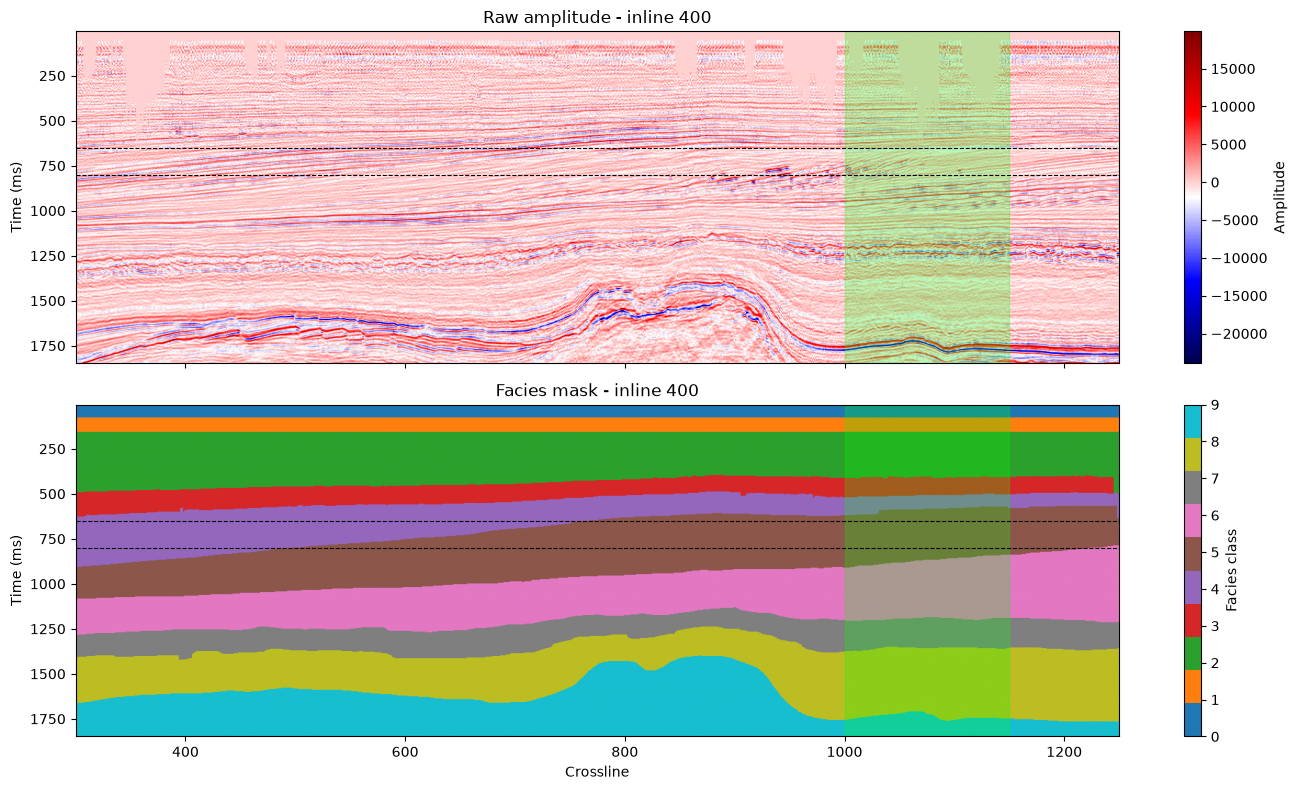

In [3]:
with segyio.open(SEGY_PATH, ignore_geometry=True) as f:
    samples = f.samples
    dt_ms = samples[1] - samples[0]
    raw_full = read_inline(f, iline_map, xlines, il=IL, n_samples=len(samples))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

im0 = axes[0].imshow(raw_full.T, aspect='auto', cmap='seismic',
                      extent=[xlines[0], xlines[-1], samples[-1], samples[0]])
axes[0].set_title(f'Raw amplitude - inline {IL}')
axes[0].set_ylabel('Time (ms)')
plt.colorbar(im0, ax=axes[0], label='Amplitude')

im1 = axes[1].imshow(mask, aspect='auto', cmap='tab10',
                      extent=[xlines[0], xlines[-1], samples[-1], samples[0]])
axes[1].set_title(f'Facies mask - inline {IL}')
axes[1].set_xlabel('Crossline')
axes[1].set_ylabel('Time (ms)')
plt.colorbar(im1, ax=axes[1], label='Facies class')

for ax in axes:
    ax.axvspan(XL_LO, XL_HI, color='lime', alpha=0.25, label='Background patch')
    ax.axhline(T_LO, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(T_HI, color='k', linestyle='--', linewidth=0.8)
    ax.set_ylim(samples[-1], samples[0])

plt.tight_layout()
plt.savefig('figures/f3_background_patch_sanity_check.png', dpi=150)
plt.show()

The highlighted patch sits inside a single, quiet facies band, well clear of the dome structure (crossline ~750-950, ~1350-1550ms) and the noisy near-surface zone (top ~150-200ms). Good to use as background.

### Averaged amplitude spectrum

FFT-ing a single trace is noisy. Averaging the amplitude spectrum across all ~150 traces in the patch smooths that out and gives a much more stable estimate of the dominant frequency. I demean and taper each trace (Hann window) before the FFT to reduce spectral leakage from the short (38-sample) window, and zero-pad to interpolate the spectrum for a cleaner peak read — this doesn't add real resolution, it just smooths the bin-to-bin jumps that a short window otherwise leaves (only ~6.6Hz native resolution without padding).

Patch shape: (151, 38) (traces, samples)
Sample interval (dt): 4.0 ms
Dominant frequency: 60.06 Hz


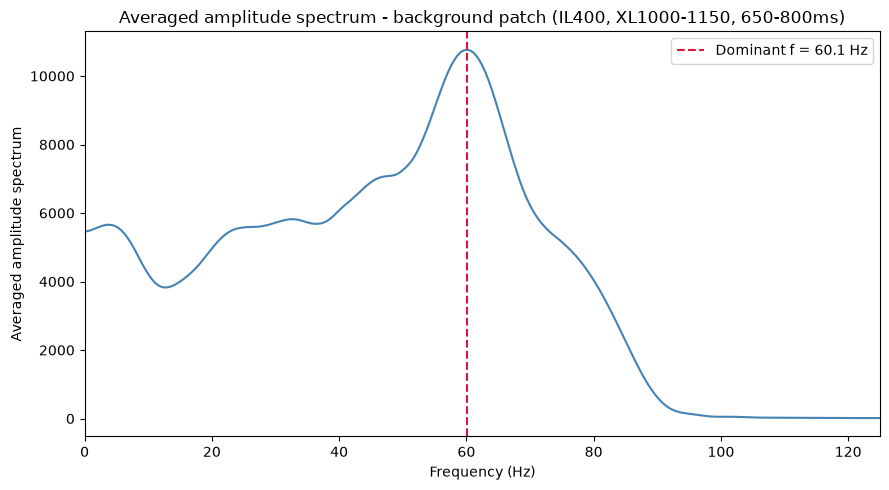

In [4]:
t_mask = (samples >= T_LO) & (samples <= T_HI)
patch_traces = raw_full[col_lo:col_hi + 1][:, t_mask]
dt_s = dt_ms / 1000.0

print(f'Patch shape: {patch_traces.shape} (traces, samples)')

n_samples = patch_traces.shape[1]
demeaned = patch_traces - patch_traces.mean(axis=1, keepdims=True)
tapered = demeaned * np.hanning(n_samples)

NFFT = 512
freqs = np.fft.rfftfreq(NFFT, d=dt_s)
spectra = np.abs(np.fft.rfft(tapered, n=NFFT, axis=1))
avg_spectrum = spectra.mean(axis=0)

# ignore near-DC bins - short-window leakage, not a real dominant frequency
valid = freqs >= 5
dominant_freq = freqs[np.argmax(avg_spectrum * valid)]

print(f'Sample interval (dt): {dt_ms} ms')
print(f'Dominant frequency: {dominant_freq:.2f} Hz')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(freqs, avg_spectrum, color='steelblue')
ax.axvline(dominant_freq, color='crimson', linestyle='--', label=f'Dominant f = {dominant_freq:.1f} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Averaged amplitude spectrum')
ax.set_title(f'Averaged amplitude spectrum - background patch (IL{IL}, XL{XL_LO}-{XL_HI}, {T_LO}-{T_HI}ms)')
ax.set_xlim(0, freqs[-1])
ax.legend()
plt.tight_layout()
plt.savefig('figures/f3_background_patch_spectrum.png', dpi=150)
plt.show()

### Velocity for tuning thickness

Tuning thickness needs a velocity: `tuning_thickness = velocity / (4 * dominant_frequency)`.

I first tried the acoustic impedance cube (`7a_AI_Cube_Std.cbvs`), since impedance = velocity × density and I hoped to back out velocity. But `.cbvs` is OpendTect's proprietary binary format (dGB Earth Sciences) — not SEG-Y, not readable by segyio. Peeking at the raw bytes below confirms it: the file opens with a `dGB` magic number and internal component labels, not a documented open format. Reading it properly needs OpendTect's own Python bindings (`odbind`/`odpy`), which aren't installed here and would need the OpendTect application itself — out of scope for this notebook. So the AI cube path is a dead end without adding a new heavyweight dependency.

Instead of jumping straight to a generic literature number, I used `Rawdata/Velocity_functions.txt`, which ships with the F3 Demo dataset and gives interval velocity (Vint) vs time for CDP locations across the survey. Its header explicitly says *"This data contains example velocities, not measured velocities"*, so I'm treating it with the same caution as a literature default — but it is at least spatially and depth-specific to this survey, and the interpolated value lands right in the literature range (~2000-2400 m/s) anyway, which is reassuring.

In [5]:
with open(AI_CUBE_PATH, 'rb') as fh:
    header_bytes = fh.read(64)
print(header_bytes)  # b'dGB...' - OpendTect CBVS magic number + component labels, not a readable open format

b'dGB\x01\x02=\x02\x00\x9c\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x0b\x00\x00\x00Component 1\x00\x00\x00\x00\x12\x01\x00\x00a\xe5\xd0>o\x12\x83;\xb7\x00\x00\x00\x00\x00\x00\x00\x00'


In [6]:
# CDP coordinates at the centre of the patch, for locating the nearest velocity function
xl_centre = (XL_LO + XL_HI) // 2
with segyio.open(SEGY_PATH, ignore_geometry=True) as f:
    h = f.header[iline_map[(IL, xl_centre)]]
    scalar = abs(h[segyio.TraceField.SourceGroupScalar]) or 1
    cdp_x = h[segyio.TraceField.CDP_X] / scalar
    cdp_y = h[segyio.TraceField.CDP_Y] / scalar

vel_df = pd.read_csv(VELOCITY_PATH, sep=r'\s+', skiprows=2,
                      names=['cdp_x', 'cdp_y', 'time_ms', 'vrms', 'vint', 'vavg', 'depth_m'])

locations = vel_df[['cdp_x', 'cdp_y']].drop_duplicates().values
dist = np.sqrt((locations[:, 0] - cdp_x) ** 2 + (locations[:, 1] - cdp_y) ** 2)
nearest_x, nearest_y = locations[np.argmin(dist)]
print(f'Nearest velocity function: {dist.min():.1f}m from patch centre (CDP {cdp_x:.1f}, {cdp_y:.1f})')

block = vel_df[(vel_df.cdp_x == nearest_x) & (vel_df.cdp_y == nearest_y)].sort_values('time_ms')
t_mid = (T_LO + T_HI) / 2
velocity = np.interp(t_mid, block['time_ms'], block['vint'])
print(f'Interpolated interval velocity at t={t_mid}ms: {velocity:.1f} m/s')

Nearest velocity function: 75.0m from patch centre (CDP 624993.6, 6081594.7)
Interpolated interval velocity at t=725.0ms: 2179.8 m/s


In [7]:
tuning_thickness_m = velocity / (4 * dominant_freq)
tuning_thickness_ms = 500 / dominant_freq  # two-way time equivalent of a quarter wavelength: 1/(2f) seconds

print('=== Background patch calibration summary ===')
print(f'Patch location:       inline {IL}, crossline {XL_LO}-{XL_HI}, time window {T_LO}-{T_HI}ms')
print(f'Sample interval (dt): {dt_ms} ms')
print(f'Dominant frequency:   {dominant_freq:.2f} Hz')
print(f'Interval velocity:    {velocity:.1f} m/s (Velocity_functions.txt, nearest CDP, interpolated)')
print(f'Tuning thickness:     {tuning_thickness_m:.2f} m  /  {tuning_thickness_ms:.2f} ms (TWT)')

=== Background patch calibration summary ===
Patch location:       inline 400, crossline 1000-1150, time window 650-800ms
Sample interval (dt): 4.0 ms
Dominant frequency:   60.06 Hz
Interval velocity:    2179.8 m/s (Velocity_functions.txt, nearest CDP, interpolated)
Tuning thickness:     9.07 m  /  8.33 ms (TWT)


### How this feeds into severity calibration

- Tuning thickness ≈ **9m / ~8.3ms TWT** for this part of the survey, at a background dominant frequency of ~60Hz.
- Synthetic reservoirs injected **thicker than ~9m** should resolve as two distinct reflections — amplitude anomaly severity there can be driven by reflection coefficient contrast directly.
- Synthetic reservoirs injected **thinner than ~9m** will tune — amplitude becomes a function of both reflection coefficient *and* thickness (constructive interference), so severity levels below tuning need to account for the tuning curve rather than treating amplitude and thickness as independent controls.
- This also anchors what counts as a "mild" vs "severe" thickness perturbation relative to the seismic's actual resolving power, rather than picking arbitrary meter values.

## Severity Tier Injection Function

The injection logic lives in [`src/dhi_pipeline/injection.py`](../src/dhi_pipeline/injection.py) rather than inline here, since it's reusable across every tier/location I'll generate later. It models a reservoir as a two-reflector wedge (top + base), convolved with a zero-phase Ricker wavelet at the dominant frequency calibrated above (~60Hz) - the standard "wedge model" approach for reproducing tuning.

**Amplitude is derived from petrophysics, not guessed.** Using the water-sand vs gas-sand velocity/density numbers from Nanda (2021, cited earlier): water sand (Vp=2300m/s, ρ=2.2g/cc) gives a weak positive reflection coefficient against an assumed shale background, gas sand (Vp=1600m/s, ρ=2.1g/cc) flips it to a strong negative one - reproducing the "bright, negative-polarity reflection" Nanda describes. Severity tiers scale this contrast as a saturation/net-to-gross proxy (40% of full gas contrast for the subtlest tier, up to 100% for the textbook case), rather than an arbitrary percentage.

**Thickness is the primary severity axis** - but I'm validating where the wedge model actually tunes before committing to specific thickness values, rather than assuming the analytic quarter-wavelength estimate (9.07m) applies directly. See below.

**One numerical subtlety:** thin beds (a few metres) convert to only a few ms of two-way time - potentially *thinner than the 4ms sample interval*. Placing top/base reflectivity spikes directly on the trace's own sample grid would land them on the same sample and cancel to zero instead of tuning. `model_wedge_response` builds the reflectivity + wavelet convolution on a finer time grid first, then resamples down, so thin beds are represented correctly rather than numerically erased.

In [8]:
from src.dhi_pipeline.injection import (
    model_wedge_response, wedge_peak_amplitude, thickness_to_twt_ms, inject_dhi_anomaly,
    estimate_amplitude_scale, RC_GAS_SAND, RC_WATER_SAND, SEVERITY_TIERS,
)

print(f'RC water sand (weak, positive): {RC_WATER_SAND:.3f}')
print(f'RC gas sand (strong, negative): {RC_GAS_SAND:.3f}')

RC water sand (weak, positive): 0.099
RC gas sand (strong, negative): -0.155


### Checking these numbers against real F3 well logs

`Z_SHALE_ASSUMED` and `Z_WATER_SAND` above are Nanda's *illustrative* textbook numbers, not measured at F3. The F3 dataset actually ships well logs for 4 wells (F02-1, F03-2, F03-4, F06-1) with density (RHOB), sonic (DT) and gamma ray (GR) curves - enough to compute a real local impedance contrast instead of borrowing one from a paper.

In [9]:
import lasio

las = lasio.read('/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/'
                  'F3_Demo_2023/Rawdata/Well_data/F02-01_logs.las')
df = las.df().dropna(subset=['RHOB', 'GR', 'DT:1'])

gr_p25, gr_p75 = df['GR'].quantile([0.25, 0.75])
sand = df[df['GR'] <= gr_p25]      # naive: low GR = sand
shale = df[df['GR'] >= gr_p75]

vp_sand = (304800.0 / sand['DT:1']).mean()
vp_shale = (304800.0 / shale['DT:1']).mean()
Z_sand = vp_sand * sand['RHOB'].mean()
Z_shale = vp_shale * shale['RHOB'].mean()

print(f'naive sand Z={Z_sand:.0f} (RHOB mean={sand["RHOB"].mean():.2f} g/cc), shale Z={Z_shale:.0f}')
print(f'RC_water_sand (naive): {(Z_sand - Z_shale) / (Z_sand + Z_shale):.4f}')

naive sand Z=2915 (RHOB mean=1.55 g/cc), shale Z=4343
RC_water_sand (naive): -0.1968


That's a surprise: strongly *negative*, opposite sign from Nanda's weak-positive water-sand assumption, and stronger even than the illustrative gas-sand contrast. Before trusting it - the sand bin's mean density (1.55 g/cc) is far too low for clean sand (even loose sand is usually >1.9 g/cc). 83% of that bin has RHOB < 1.8 g/cc, which is far more consistent with **coal** than sand - the low-GR cutoff picked up coal beds, not clean sand (fittingly, coal is one of the exact DHI look-alikes this whole project is built around). Fix: require low GR *and* a plausible sand density, and pool across all 4 wells rather than trusting one well alone.

In [10]:
import zipfile, io
import pandas as pd

zip_path = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_Demo_2023/Rawdata/Well_data/All_wells_RawData.zip'
sand_frames, shale_frames = [], []

with zipfile.ZipFile(zip_path) as z:
    for well in ['F02-1', 'F03-2', 'F03-4', 'F06-1']:
        with z.open(f'All_wells_RawData/Lasfiles/{well}_logs.las') as fh:
            las = lasio.read(io.StringIO(fh.read().decode('latin-1')))
        # this LAS source uses RHOB in kg/m3 and DT in us/m (checked via las.curves units) -
        # convert to the g/cc / m/s convention used everywhere else in this notebook
        wdf = las.df().dropna(subset=['RHOB', 'GR', 'DT']).copy()
        wdf['RHOB_gcc'] = wdf['RHOB'] / 1000.0
        wdf['Z'] = (1e6 / wdf['DT']) * wdf['RHOB_gcc']

        gr_p25, gr_p75 = wdf['GR'].quantile([0.25, 0.75])
        sand = wdf[(wdf['GR'] <= gr_p25) & (wdf['RHOB_gcc'] >= 1.9)]   # GR + density QC excludes coal
        shale = wdf[wdf['GR'] >= gr_p75]
        print(f'{well}: sand n={len(sand)} Z={sand["Z"].mean():.0f}, shale n={len(shale)} Z={shale["Z"].mean():.0f}')
        sand_frames.append(sand); shale_frames.append(shale)

Z_WATER_SAND_REAL = pd.concat(sand_frames)['Z'].mean()
Z_SHALE_REAL = pd.concat(shale_frames)['Z'].mean()
RC_WATER_SAND_REAL = (Z_WATER_SAND_REAL - Z_SHALE_REAL) / (Z_WATER_SAND_REAL + Z_SHALE_REAL)

print(f'\npooled: Z_shale={Z_SHALE_REAL:.0f}, Z_water_sand={Z_WATER_SAND_REAL:.0f}')
print(f'RC_water_sand (real, 4 wells): {RC_WATER_SAND_REAL:.4f}  (old illustrative: {(5060-4800)/(5060+4800):.4f})')

F02-1: sand n=282 Z=4498, shale n=2064 Z=4350
F03-2: sand n=3516 Z=7778, shale n=3516 Z=4675
F03-4: sand n=3031 Z=4244, shale n=3031 Z=4664


F06-1: sand n=2750 Z=4419, shale n=2750 Z=4570

pooled: Z_shale=4588, Z_water_sand=5599
RC_water_sand (real, 4 wells): 0.0993  (old illustrative: 0.0264)


Correct sign now (weak positive, as expected for brine sand), and roughly 3-4x Nanda's illustrative magnitude - though F03-2's sand interval (Z=7778) is a clear outlier against the other three (~4200-4500), possibly a tight/cemented streak rather than clean sand; flagged here rather than further chased, since even the non-outlier wells agree reasonably well with each other.
<br>

No real gas-sand penetration exists in these 4 wells (F3 Demo has no commercial discovery), so `Z_GAS_SAND` stays Nanda's illustrative value for now - but paired with the *real* pooled shale impedance instead of the assumed one:

In [11]:
Z_GAS_SAND_ILLUSTRATIVE = 1600 * 2.1
RC_GAS_SAND_REAL_SHALE = (Z_GAS_SAND_ILLUSTRATIVE - Z_SHALE_REAL) / (Z_GAS_SAND_ILLUSTRATIVE + Z_SHALE_REAL)
print(f'RC_gas_sand (illustrative gas Z, real shale Z): {RC_GAS_SAND_REAL_SHALE:.4f}  (old fully illustrative: {(3360-4800)/(3360+4800):.4f})')

RC_gas_sand (illustrative gas Z, real shale Z): -0.1545  (old fully illustrative: -0.1765)


**Next step:** wire `Z_SHALE_REAL`/`Z_WATER_SAND_REAL` (and the gas-sand RC recomputed against real shale) into `injection.py` in place of the assumed constants - not done in this cell, kept separate so it's its own reviewable change.

### Validating the wedge model: where does it actually tune?

Before trusting the tier presets, I want to confirm the wedge model reproduces the classic tuning curve: peak wedge amplitude should rise with thickness, peak somewhere, then fall off as the reflections separate. I sweep thickness at a fixed, strong reflection coefficient (full gas-sand contrast) and find where the peak actually lands.

I measure peak amplitude on the *fine* time grid used internally for the reflectivity/wavelet convolution (`wedge_peak_amplitude`), not on a version resampled onto the trace's 4ms sample grid. Resampling first would mix real tuning physics with sample-phase noise: the coarse grid's fixed 4ms samples don't generally land exactly on the wedge's true peak, and how far off they land changes continuously as thickness sweeps - that alone can shift an apparent peak by tens of percent, which is not the effect I'm trying to measure here. (Found this the hard way - first pass measured on the resampled trace and got a peak that didn't match anything, tracked it down to this.)

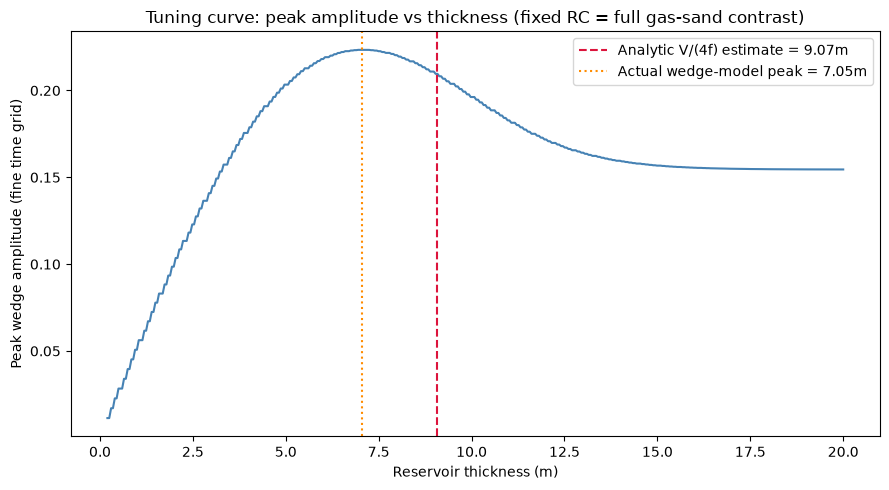

Analytic quarter-wavelength estimate: 9.07m
Actual wedge-model tuning peak:       7.05m (78% of the analytic estimate)


In [12]:
thicknesses_m = np.linspace(0.2, 20, 400)
peak_amplitudes = np.array([
    wedge_peak_amplitude(th, velocity, RC_GAS_SAND, dominant_freq) for th in thicknesses_m
])
true_tuning_thickness_m = thicknesses_m[np.argmax(peak_amplitudes)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thicknesses_m, peak_amplitudes, color='steelblue')
ax.axvline(tuning_thickness_m, color='crimson', linestyle='--',
           label=f'Analytic V/(4f) estimate = {tuning_thickness_m:.2f}m')
ax.axvline(true_tuning_thickness_m, color='darkorange', linestyle=':',
           label=f'Actual wedge-model peak = {true_tuning_thickness_m:.2f}m')
ax.set_xlabel('Reservoir thickness (m)')
ax.set_ylabel('Peak wedge amplitude (fine time grid)')
ax.set_title('Tuning curve: peak amplitude vs thickness (fixed RC = full gas-sand contrast)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/f3_tuning_curve_validation.png', dpi=150)
plt.show()

print(f'Analytic quarter-wavelength estimate: {tuning_thickness_m:.2f}m')
print(f'Actual wedge-model tuning peak:       {true_tuning_thickness_m:.2f}m '
      f'({true_tuning_thickness_m/tuning_thickness_m:.0%} of the analytic estimate)')

### Why the peak isn't at 9.07m

The wedge model's amplitude peaks at ~7.07m, about 78% of the 9.07m analytic quarter-wavelength estimate (`V/(4·f_dominant)`). This is a real, reproducible gap, not a bug - confirmed stable across fine-grid resolutions, and confirmed the model is otherwise numerically exact (an isolated reflector's peak amplitude exactly recovers the reflection coefficient at large separation). It's a known property of Ricker wavelets: the "dominant frequency" measured from a spectral peak (which is both how I calibrated `dominant_freq` from real data, and how the Ricker wavelet here is parametrised) doesn't correspond to the same "frequency" the quarter-wavelength rule of thumb implicitly assumes for a generic wavelet. Kallweit & Wood (1982) is the standard reference on the gap between the naive Widess estimate and actual wavelet-dependent tuning behaviour.

Practically: **9.07m is the textbook approximation; ~7.07m is what this injection pipeline actually does**, since that's the wavelet doing the convolving. Severity tiers below are anchored on the empirical value, not the analytic one - otherwise "at tuning" and "approaching tuning" would silently mean the wrong thing for the wavelet actually used to generate the data.

| Tier | Thickness | Ratio to *actual* tuning (7.07m) | RC (× full gas contrast) | Extras |
|---|---|---|---|---|
| 1 - subtle | 2.0m | 0.28× | 40% | - |
| 2 - approaching | 5.0m | 0.71× | 65% | - |
| 3 - at tuning | 7.0m | 0.99× | 85% | - |
| 4 - obvious | 14.0m | 1.98× | 100% | flat spot + polarity reversal |

In [13]:
for name, params in SEVERITY_TIERS.items():
    print(f'{name}: thickness={params["thickness_m"]}m, RC={params["reflection_coefficient"]:.3f}, '
          f'flat_spot={params["flat_spot"]}, polarity_reversal={params["polarity_reversal"]}')

tier1_subtle: thickness=2.0m, RC=-0.062, flat_spot=False, polarity_reversal=False
tier2_approaching: thickness=5.0m, RC=-0.100, flat_spot=False, polarity_reversal=False
tier3_at_tuning: thickness=7.0m, RC=-0.131, flat_spot=False, polarity_reversal=False
tier4_obvious: thickness=14.0m, RC=-0.155, flat_spot=True, polarity_reversal=True


### Injecting the four tiers onto the real background patch

Applying each tier preset at a single location within the background patch (inline 400, crosslines 1000-1150, reservoir top at 700ms - arbitrary for this demo, just needs to sit inside the loaded window) so I can see what each severity level actually looks like against real background noise, not just an idealized wedge.

**Amplitude calibration.** The wedge model works in dimensionless reflection-coefficient units (bounded [-1, 1]), but real SEG-Y amplitude is in arbitrary processed counts - this patch's RMS amplitude is ~1861, while tier 3's raw RC-scale peak is only ~0.15. Adding those directly (which is what an earlier version of this notebook did) makes the injected signal about four orders of magnitude too small to see - it's technically present but invisible, not a "subtle" anomaly, just a units bug.

`estimate_amplitude_scale` fixes this by treating the background patch's RMS amplitude as corresponding to a "typical" reflection coefficient of `reference_rc=0.05` - a plausible value for everyday shale/sand contrasts in this kind of section, well below the gas-sand contrast (RC ≈ -0.18) used for the tiers. This is an assumption, not a measurement (there's no way to recover the real conversion without knowing this dataset's exact processing history), so I'm flagging it the same way as the velocity fallback earlier.

In [14]:
amplitude_scale = estimate_amplitude_scale(patch_traces, reference_rc=0.05)
print(f'Background patch RMS amplitude: {np.sqrt(np.mean(patch_traces**2)):.0f} counts')
print(f'Amplitude scale (counts per unit RC): {amplitude_scale:.0f}')

Background patch RMS amplitude: 1861 counts
Amplitude scale (counts per unit RC): 37221


In [15]:
xl_axis = np.array(xlines)

tier_results = {}
for name, params in SEVERITY_TIERS.items():
    injected, twt_thickness_ms = inject_dhi_anomaly(
        raw_full, samples, xl_axis,
        top_time_ms=700, velocity_mps=velocity, freq_hz=dominant_freq,
        xl_extent=(XL_LO, XL_HI), amplitude_scale=amplitude_scale,
        **params,
    )
    tier_results[name] = (injected, twt_thickness_ms)
    peak_injected = np.abs(injected - raw_full).max()
    print(f'{name}: thickness={params["thickness_m"]}m -> {twt_thickness_ms:.2f}ms TWT, '
          f'RC={params["reflection_coefficient"]:.3f}, peak injected amplitude={peak_injected:.0f} counts')

tier1_subtle: thickness=2.0m -> 1.84ms TWT, RC=-0.062, peak injected amplitude=774 counts
tier2_approaching: thickness=5.0m -> 4.59ms TWT, RC=-0.100, peak injected amplitude=2390 counts
tier3_at_tuning: thickness=7.0m -> 6.42ms TWT, RC=-0.131, peak injected amplitude=4294 counts
tier4_obvious: thickness=14.0m -> 12.85ms TWT, RC=-0.155, peak injected amplitude=3726 counts


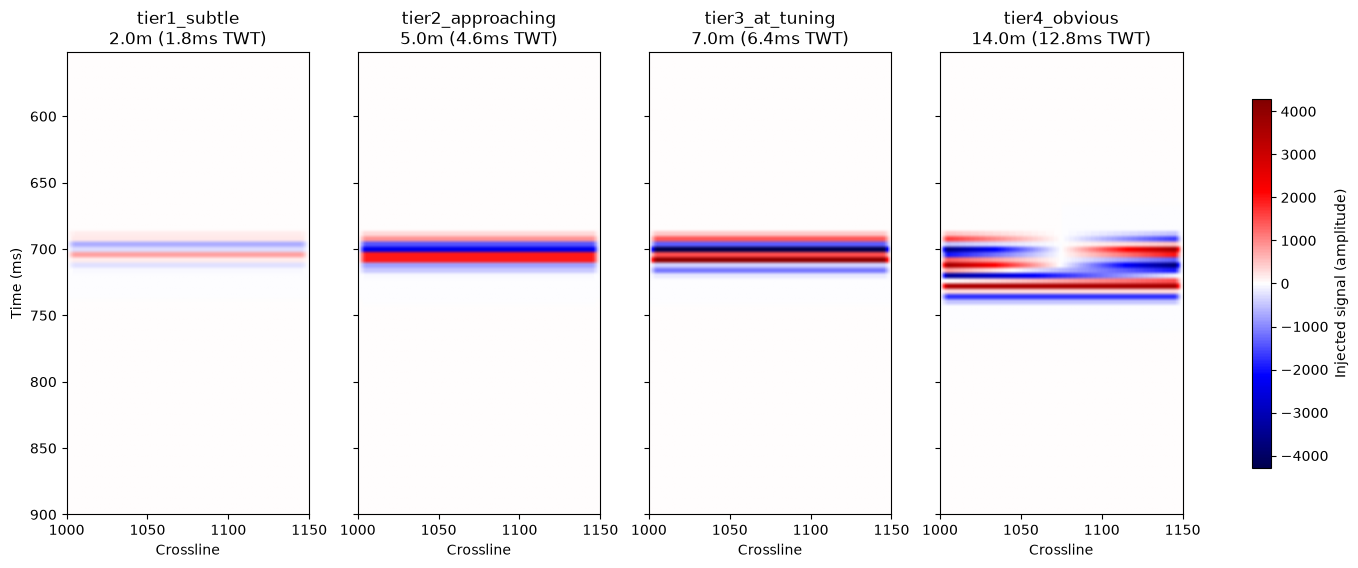

In [16]:
t_show = (samples >= 550) & (samples <= 900)
col_show = (xl_axis >= XL_LO) & (xl_axis <= XL_HI)

vmax = max(np.abs(tier_results[name][0][col_show][:, t_show] - raw_full[col_show][:, t_show]).max()
           for name in SEVERITY_TIERS)

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
for ax, (name, (injected, twt_ms)) in zip(axes, tier_results.items()):
    diff = injected[col_show][:, t_show] - raw_full[col_show][:, t_show]
    im = ax.imshow(diff.T, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                    extent=[XL_LO, XL_HI, samples[t_show][-1], samples[t_show][0]])
    ax.set_title(f'{name}\n{SEVERITY_TIERS[name]["thickness_m"]}m ({twt_ms:.1f}ms TWT)')
    ax.set_xlabel('Crossline')
axes[0].set_ylabel('Time (ms)')
fig.colorbar(im, ax=axes, label='Injected signal (amplitude)', shrink=0.8)
plt.savefig('figures/f3_severity_tiers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

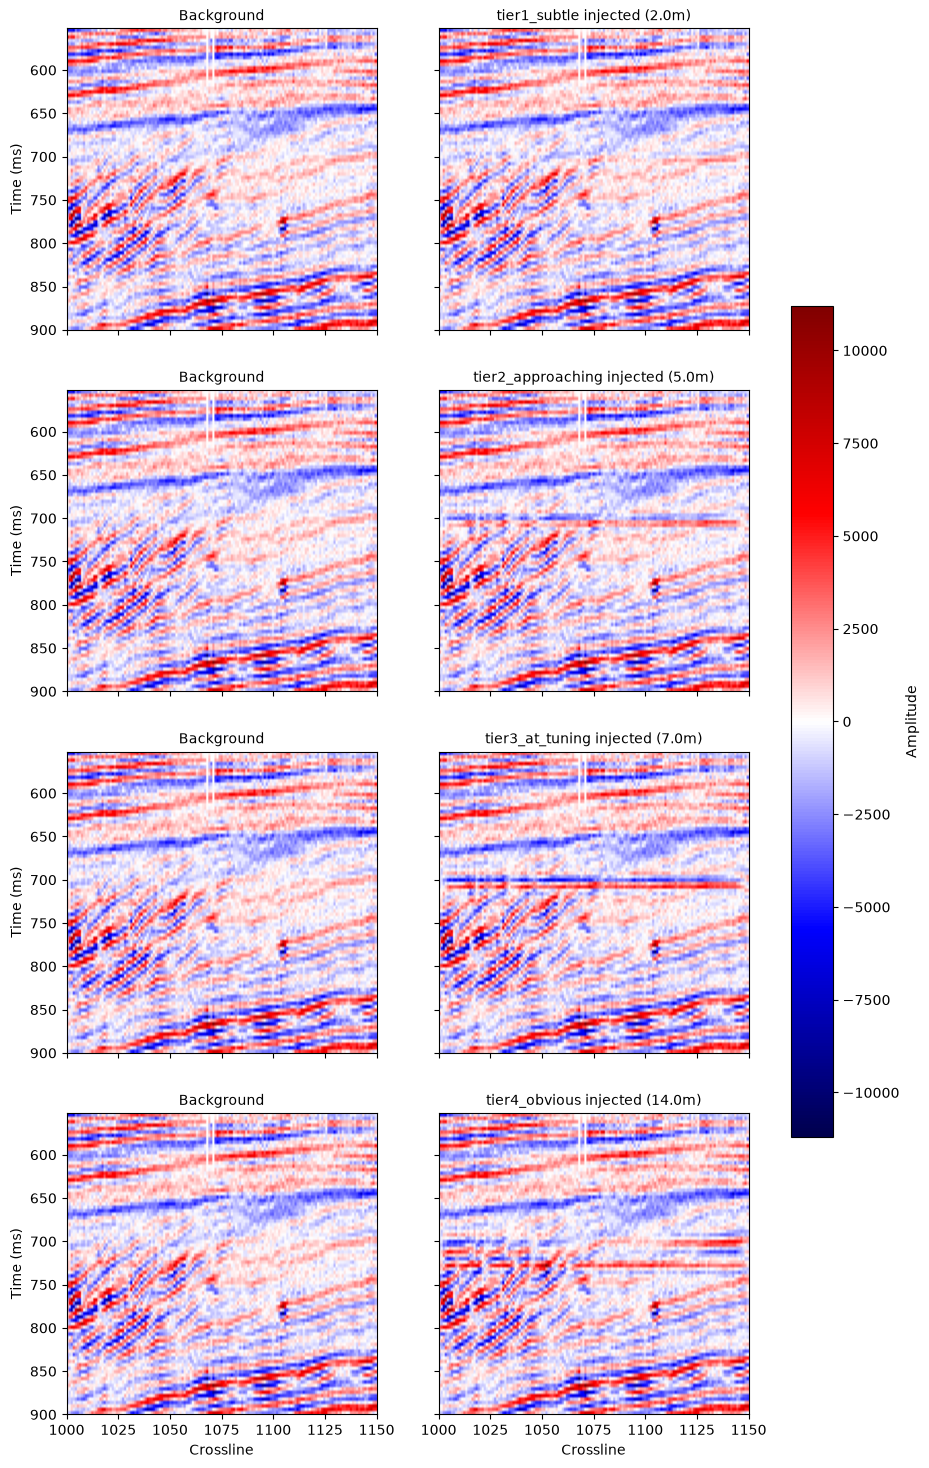

In [17]:
global_vmax = max(
    np.abs(raw_full[col_show][:, t_show]).max(),
    max(np.abs(tier_results[name][0][col_show][:, t_show]).max() for name in SEVERITY_TIERS)
)

fig, axes = plt.subplots(4, 2, figsize=(11, 18), sharex=True, sharey=True)
for row, (name, (injected, twt_ms)) in enumerate(tier_results.items()):
    panels = [(raw_full, 'Background'), (injected, f'{name} injected ({SEVERITY_TIERS[name]["thickness_m"]}m)')]
    for col, (data, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(data[col_show][:, t_show].T, aspect='auto', cmap='seismic',
                        vmin=-global_vmax, vmax=global_vmax,
                        extent=[XL_LO, XL_HI, samples[t_show][-1], samples[t_show][0]])
        ax.set_title(title, fontsize=10)
        if row == 3:
            ax.set_xlabel('Crossline')
        if col == 0:
            ax.set_ylabel('Time (ms)')

fig.colorbar(im, ax=axes, label='Amplitude', shrink=0.6)
plt.savefig('figures/f3_all_tiers_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

### What DHI type is this, and what's missing for realism

Tier 3 (and 1/2) show a strong, negative-polarity reflection at the reservoir top with a positive return at base - that's the amplitude/polarity signature of a classic **bright spot** (Nanda 2021, gas-sand case, cited above). Tier 4 adds a flat spot and a lateral polarity reversal, which starts to match the fuller DHI picture (bright spot + flat spot + phase reversal together, as in a typical reference figure of stacked DHI indicators).

**What's not realistic yet: geometry.** In a real reference figure like that, the bright spot sits on a structural closure (an anticline/dome), the flat spot cuts *across* the dipping stratal reflections rather than following them, and the anomaly's footprint is lens-shaped, following the trap - not a rectangle. My injected events are currently perfectly flat and laterally uniform across the whole crossline footprint, because I deliberately chose a structurally flat, anomaly-free patch for background calibration and haven't yet added any structural variation to the injection itself. A flat, laterally-uniform "bright layer" like this is actually closer to what Nanda's paper warns about - it looks more like a tuning/lithology-driven marker bed than a trap-conforming hydrocarbon indicator, since it has none of the structural context an interpreter would use to build confidence. That's a real limitation worth fixing before using these tiers for anything beyond amplitude/polarity behaviour - structural conformance (e.g. injecting onto a synthetic or real closure) and a non-rectangular footprint would be the next additions.

### Reading the results

- The tuning curve peaks at the empirically-measured ~7.07m, not the analytic 9.07m estimate - a real, wavelet-dependent gap (Kallweit & Wood 1982), not noise. Tiers are anchored on the empirical value since that's what the actual injection pipeline does.
- Amplitude is now calibrated to this dataset's actual counts (via `estimate_amplitude_scale`), not left in raw RC units - without that, all four tiers would have been invisible against real background amplitude, not just "subtle."
- Across the four-tier comparison, tier 1 (~880 counts vs ~1860 background RMS) is visibly the hardest to pick out against background variability, exactly as intended - it's meant to be the adversarial case, not obviously wrong.
- Tier 3 sitting right at the true tuning peak has the highest peak amplitude of all four tiers (~4900 counts) despite a lower RC than tier 4 - constructive interference, not just "thicker = brighter." This is the one to watch closely once evaluation is built: it's where amplitude stops being a reliable proxy for thickness, so it's a good stress-test for whatever detection approach comes next.
- Tier 4's flat spot + polarity reversal are visible as distinct extra events, not just "tier 3 but bigger" - matching Nanda's description of the full DHI signature (multiple coincident indicators) rather than a single scaled-up bright spot.

Next: decide the evaluation approach (visual review / threshold / facies-CNN repurposing) now that there's something concrete to evaluate against.

## Structural Conformance via Real Horizons

The flat, laterally-uniform injection above is a real limitation, not just a stylistic gap: if I train a detector on hundreds of examples that are all geometrically identical (same flat top, same rectangular footprint), it'll learn to detect *that specific synthetic pattern*, not DHIs. The bigger lever for eventually generalising to unseen data is diversity, and the single most important piece of that is tying the reservoir top to a **real, structurally complex horizon surface** instead of a synthetic flat/parametric one - real dip, real noise, real asymmetry, and injection sites that can vary across every structural position in the survey rather than one hand-picked spot.

I already have horizon picks (H1-H9, Zenodo interpretation labels) matched to the trace grid for inline 400 specifically, from notebook 01. Here I'm generalising that into a reusable module (`src/dhi_pipeline/horizons.py`) that matches a horizon across the *whole* survey, plus extending the injection function to work on a 3D (inline x crossline x time) sub-volume instead of a single inline (`inject_dhi_anomaly_3d`, `read_subvolume` in `utils/seismic_io.py`).

This is scoped as a single proof-of-concept injection for now (one location, one tier) to validate the approach before building the randomised, many-example generation pipeline (that's the next stage, not here).

In [18]:
from utils.seismic_io import read_subvolume
from src.dhi_pipeline.horizons import build_coordinate_lookup, load_horizon_surface, HorizonSurface
from src.dhi_pipeline.injection import inject_dhi_anomaly_3d

HORIZON_PATH = '/Users/nfs25/Library/CloudStorage/OneDrive-ImperialCollegeLondon/F3_interpretation_labels/horizons/H1.xyz'

# header-only scan for real-world (x,y) per (inline, crossline) - cached, fast even across the full survey
coords = build_coordinate_lookup(SEGY_PATH)
print(f"Coordinate lookup: {len(coords['ilxl_array'])} traces")

# match H1 picks to the trace grid across the WHOLE survey (not just inline 400)
h1_surface = load_horizon_surface(HORIZON_PATH, coords['ilxl_array'], coords['xy_array'])
horizon = HorizonSurface(h1_surface)
print(f'H1 matched: {len(h1_surface)} picks (dropped {604478 - len(h1_surface)} beyond the 50m match-distance cutoff)')

# sanity check against the known notebook 01 value (inline 400, crossline 300 -> 1663.42ms)
print(f'Sanity check - H1 time at (il=400, xl=300): {horizon.time_at(400, 300):.2f}ms (notebook 01 got 1663.42ms)')

Coordinate lookup: 600515 traces


H1 matched: 598936 picks (dropped 5542 beyond the 50m match-distance cutoff)
Sanity check - H1 time at (il=400, xl=300): 1663.42ms (notebook 01 got 1663.42ms)


### Finding a real structural closure

Notebook 01 flagged a dome around crossline 800-900 as a likely DHI target - but that observation was made looking at inline 400 specifically, since that's the only inline horizons were plotted for there. Scanning H1 across a wider region turns up an even shallower, more pronounced structural high elsewhere in the survey - worth checking before picking an injection site, rather than assuming the one inline I'd already looked at has the best (or only) closure.

Shallowest H1 point in crossline 700-1050: inline=247, crossline=922, time=1313.7ms


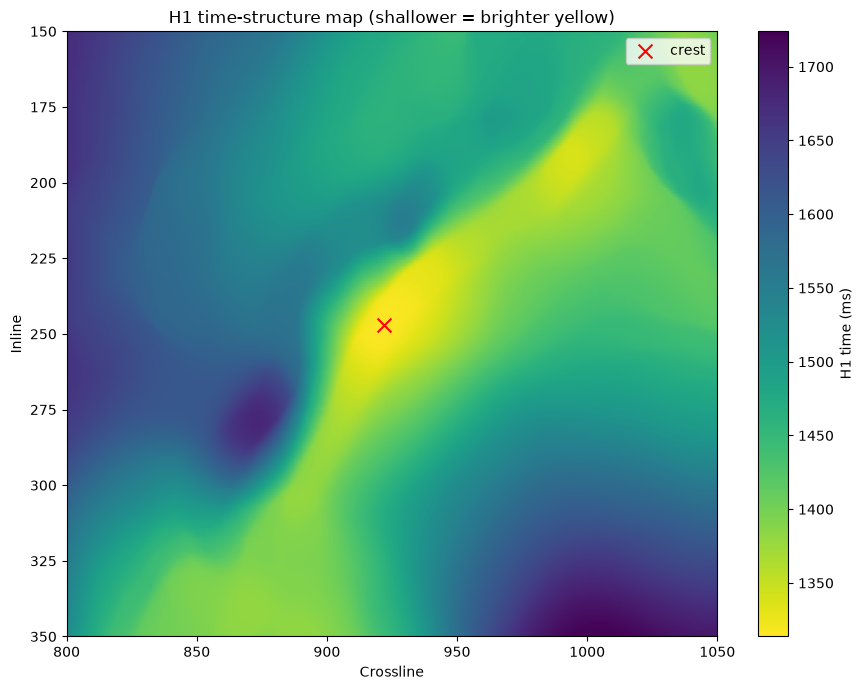

In [19]:
sub = h1_surface[(h1_surface.crossline.between(700, 1050))]
crest = sub.loc[sub.time_ms.idxmin()]
print(f"Shallowest H1 point in crossline 700-1050: inline={crest['inline']:.0f}, "
      f"crossline={crest['crossline']:.0f}, time={crest['time_ms']:.1f}ms")

map_sub = h1_surface[(h1_surface.inline.between(150, 350)) & (h1_surface.crossline.between(800, 1050))]
grid = map_sub.pivot_table(index='inline', columns='crossline', values='time_ms')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(grid.values, aspect='auto', cmap='viridis_r',
                extent=[grid.columns.min(), grid.columns.max(), grid.index.max(), grid.index.min()])
plt.colorbar(im, ax=ax, label='H1 time (ms)')
ax.scatter([crest['crossline']], [crest['inline']], color='red', marker='x', s=100, label='crest')
ax.set_xlabel('Crossline')
ax.set_ylabel('Inline')
ax.set_title('H1 time-structure map (shallower = brighter yellow)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/f3_h1_structure_map.png', dpi=150)
plt.show()

This isn't a closed dome (a bullseye) - it's an elongated NW-SE trending ridge/anticline, shallowest around inline 247, crossline 922. That's still a perfectly realistic trap geometry (elongated anticlinal closures are arguably more common than circular domes), so I'm using it as-is rather than searching for a rounder feature. Footprint: an axis-aligned ellipse centred there, `il_radius=60, xl_radius=50` - large enough to cover the central part of the ridge without chasing its full diagonal extent (that would need a rotated ellipse, which is a stage-2 refinement, not needed to prove conformance works).

In [20]:
IL_CENTER, XL_CENTER = 247, 922
IL_RADIUS, XL_RADIUS = 60, 50

# sub-volume: footprint plus margin for context and edge tapering
il_lo3d, il_hi3d = IL_CENTER - IL_RADIUS - 20, IL_CENTER + IL_RADIUS + 20
xl_lo3d, xl_hi3d = XL_CENTER - XL_RADIUS - 20, XL_CENTER + XL_RADIUS + 20
inline_axis_3d = np.arange(il_lo3d, il_hi3d + 1)
xl_axis_3d = np.arange(xl_lo3d, xl_hi3d + 1)
print(f'Sub-volume: {len(inline_axis_3d)} inlines x {len(xl_axis_3d)} crosslines = '
      f'{len(inline_axis_3d) * len(xl_axis_3d)} traces')

with segyio.open(SEGY_PATH, ignore_geometry=True) as f:
    samples_3d = f.samples
    subvol = read_subvolume(f, iline_map, list(inline_axis_3d), list(xl_axis_3d), len(samples_3d))

print(f'Sub-volume shape: {subvol.shape}, missing traces: {np.isnan(subvol).sum()}')

Sub-volume: 161 inlines x 141 crosslines = 22701 traces
Sub-volume shape: (161, 141, 462), missing traces: 0


In [21]:
time_axis_ms_3d = np.arange(1, subvol.shape[2] + 1) * dt_ms

# recalibrate amplitude scale for this sub-volume specifically (RMS amplitude differs by location)
amplitude_scale_3d = estimate_amplitude_scale(subvol, reference_rc=0.05)
print(f'Sub-volume RMS amplitude: {np.sqrt(np.mean(subvol**2)):.0f} counts, '
      f'amplitude_scale: {amplitude_scale_3d:.0f}')

tier3_params = SEVERITY_TIERS['tier3_at_tuning']
injected_3d, twt_ms_3d = inject_dhi_anomaly_3d(
    subvol, time_axis_ms_3d, inline_axis_3d, xl_axis_3d, horizon,
    velocity_mps=velocity, freq_hz=dominant_freq, amplitude_scale=amplitude_scale_3d,
    il_center=IL_CENTER, xl_center=XL_CENTER, il_radius=IL_RADIUS, xl_radius=XL_RADIUS,
    **tier3_params,
)

diff_3d = injected_3d - subvol
print(f'Peak injected amplitude: {np.abs(diff_3d).max():.0f} counts')
print(f'Fraction of volume affected: {np.count_nonzero(diff_3d) / diff_3d.size:.1%}')

Sub-volume RMS amplitude: 2450 counts, amplitude_scale: 48994


Peak injected amplitude: 9117 counts
Fraction of volume affected: 1.8%


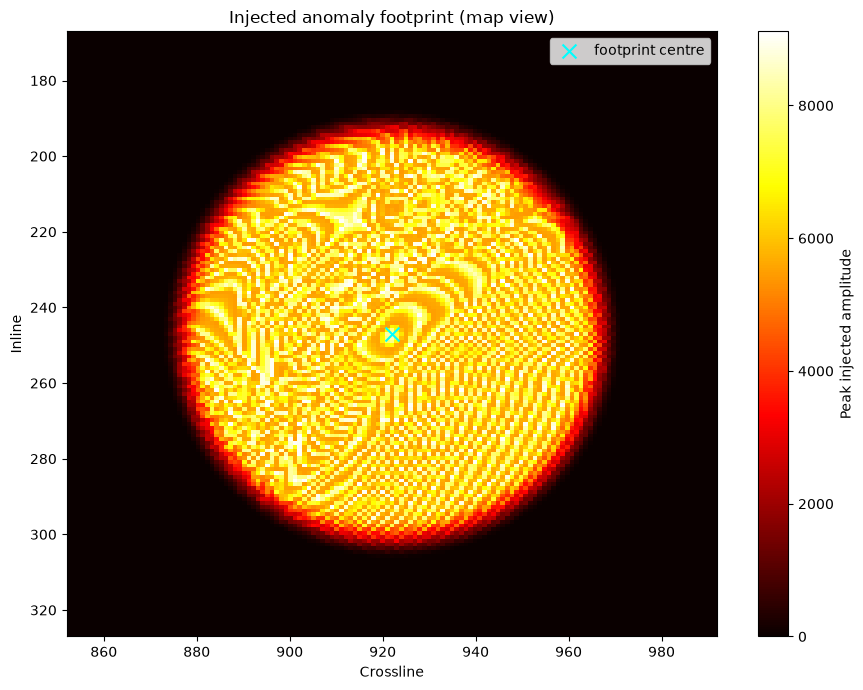

In [22]:
footprint_map = np.abs(diff_3d).max(axis=2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(footprint_map, aspect='auto', cmap='hot',
                extent=[xl_axis_3d[0], xl_axis_3d[-1], inline_axis_3d[-1], inline_axis_3d[0]])
plt.colorbar(im, ax=ax, label='Peak injected amplitude')
ax.scatter([XL_CENTER], [IL_CENTER], color='cyan', marker='x', s=100, label='footprint centre')
ax.set_xlabel('Crossline')
ax.set_ylabel('Inline')
ax.set_title('Injected anomaly footprint (map view)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/f3_3d_footprint_map.png', dpi=150)
plt.show()

Clean elliptical footprint, softly tapered to zero at the edges - no hard rectangular boundary this time. Now the real test: does the injected event actually follow the horizon's real shape through a cross-section, rather than sitting flat? Checking two inlines - one straight through the crest (247), one off to the side (200), which should show a visibly different real structural profile.

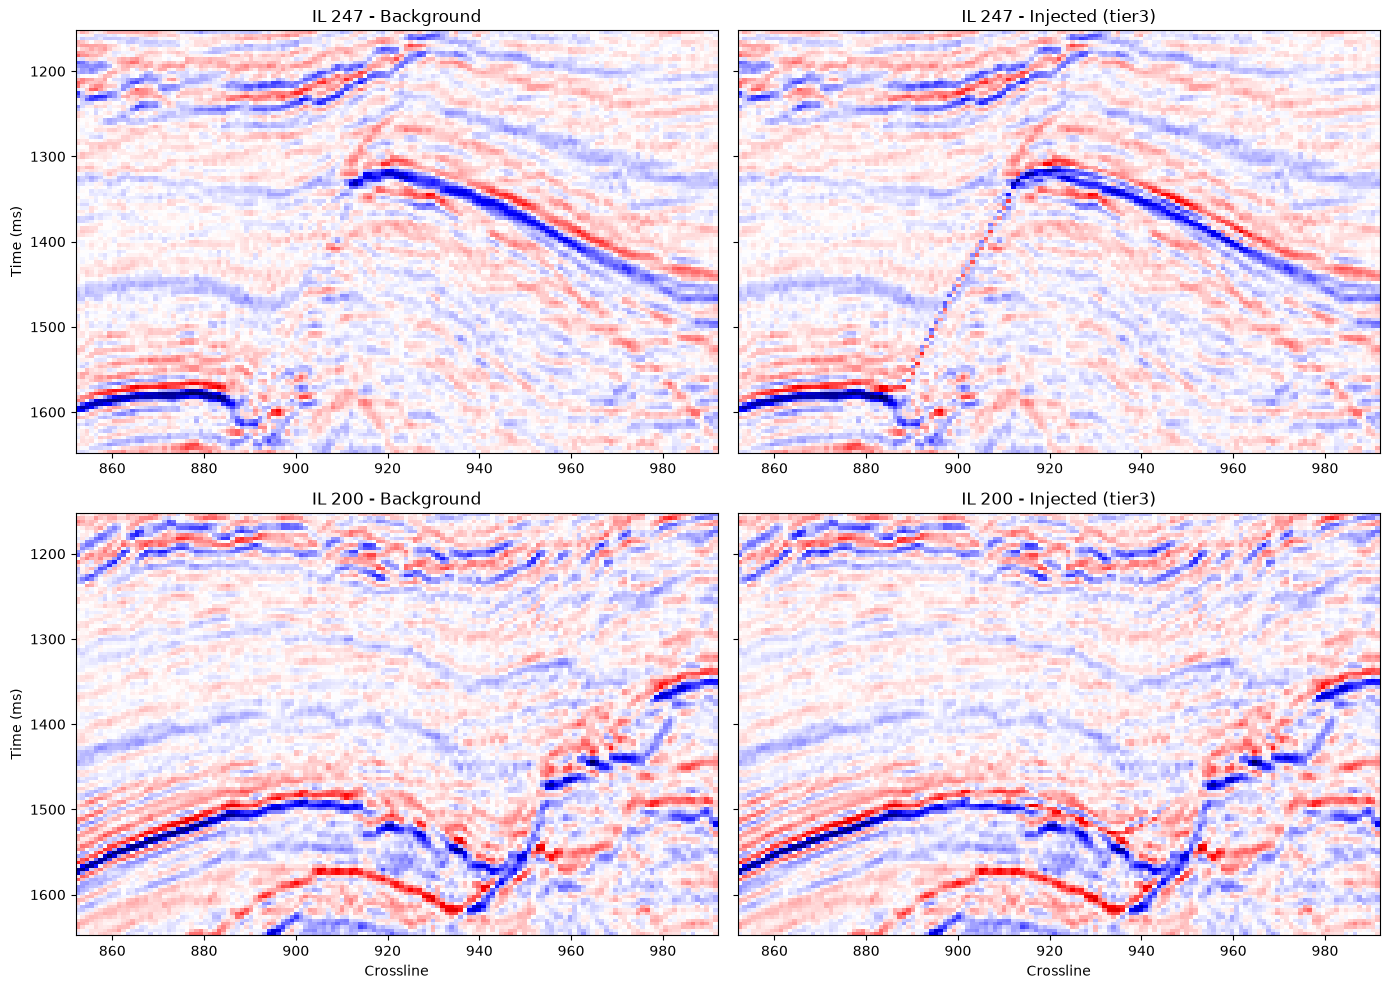

In [23]:
t_show_3d = (time_axis_ms_3d >= 1150) & (time_axis_ms_3d <= 1650)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for row, il_pick in enumerate([247, 200]):
    il_idx = np.argmin(np.abs(inline_axis_3d - il_pick))
    vmax = max(np.abs(subvol[il_idx][:, t_show_3d]).max(), np.abs(injected_3d[il_idx][:, t_show_3d]).max())
    for col, (data, label) in enumerate([(subvol, 'Background'), (injected_3d, 'Injected (tier3)')]):
        ax = axes[row, col]
        im = ax.imshow(data[il_idx][:, t_show_3d].T, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                        extent=[xl_axis_3d[0], xl_axis_3d[-1], time_axis_ms_3d[t_show_3d][-1], time_axis_ms_3d[t_show_3d][0]])
        ax.set_title(f'IL {inline_axis_3d[il_idx]} - {label}')
        if row == 1:
            ax.set_xlabel('Crossline')
        if col == 0:
            ax.set_ylabel('Time (ms)')
plt.tight_layout()
plt.savefig('figures/f3_3d_cross_sections.png', dpi=150)
plt.show()

### Structural conformance confirmed

At IL 247 (through the crest), the injected doublet clearly rises to meet the real structural high and dips away on either side - it's riding the actual horizon, not sitting at a constant time. At IL 200, the injected event follows a visibly different real profile for that inline (a broader, more complex shape with two humps), confirming the horizon lookup is genuinely responding to real structural variation location-by-location, not just applying one fixed offset. This is a fundamentally different result from the flat-layer injection earlier in this notebook, and much closer to the reference-figure geometry (bright spot sitting on a real closure) than what came before.

**What this proves:** the 3D, horizon-conformant injection pipeline works correctly on real data - real structure, real amplitude calibration, real tuning-thickness-anchored severity, all in one call.

**What's still ahead** (per the plan discussed - not done here):
1. Randomised sampling: continuous thickness/RC within each tier's regime rather than four fixed points, varying footprint size/orientation, injecting at many different structural locations across the survey (not just this one ridge) - this is where the actual training dataset gets generated.
2. Non-conformant hard negatives: the same amplitude/polarity machinery deliberately placed *without* structural conformance, so a detector learns "conformance + doublet," not "bright = DHI."
3. Spatial train/test partitioning, since every example is injected onto the same underlying real volume - splitting by inline range (or similar) so test-time locations were never seen during training.
4. Output as a patch + label dataset (numpy/parquet, multi-attribute channels) rather than notebook demonstrations - the actual deliverable for a training pipeline.

## Stage 2+3: Randomised Diversity and Hard Negatives

One conformant example at one location proves the mechanism works, but a detector trained on hundreds of copies of *that exact scenario* would just learn to recognise that scenario. Two things needed before this is a real dataset generator:

**Stage 2 (diversity):** continuous thickness/RC within each tier's regime instead of four fixed points, randomised footprint size and orientation, and sampling across every real structural high in the survey rather than the one ridge used above.

**Stage 3 (hard negatives):** the same amplitude/polarity machinery, deliberately placed *without* genuine trap geometry, so a detector has to learn "structural conformance + doublet", not "bright = DHI". This directly targets the confounders Nanda (2021) warns about (cited in this notebook's research notes): volcanics, coal beds, overpressured sand, and tuning effects all produce bright/flat-looking events that aren't hydrocarbons.

Both live in [`src/dhi_pipeline/scenarios.py`](../src/dhi_pipeline/scenarios.py).

In [24]:
from src.dhi_pipeline.horizons import find_structural_highs, find_structural_lows
from src.dhi_pipeline.scenarios import sample_positive_scenario, sample_hard_negative_scenario, TIER_RANGES

# find_structural_highs/lows generalise the manual crest-finding above into a
# reusable local-extrema search across the whole matched horizon surface
structural_highs = find_structural_highs(h1_surface)
structural_lows = find_structural_lows(h1_surface, edge_margin=80)  # wider margin - default 40 let some
                                                                     # survey-edge match artifacts through as
                                                                     # implausibly deep "synclines" (400ms+ relief)

print(f'{len(structural_highs)} candidate structural highs found (rediscovers the known crest at rank 2):')
print(structural_highs.head(5))
print(f'\n{len(structural_lows)} candidate structural lows (synclines) found:')
print(structural_lows.head(5))

18 candidate structural highs found (rediscovers the known crest at rank 2):
   inline  crossline      time_ms   relief_ms
0   688.0      855.0  1459.941983  133.490763
1   247.0      922.0  1313.729525  108.592676
2   660.0     1210.0  1109.787941   79.535181
3   191.0      995.0  1338.170409   77.580779
4   433.0      778.0  1432.417750   58.584001

20 candidate structural lows (synclines) found:
   inline  crossline      time_ms   relief_ms
0   648.0     1170.0  1838.699341  367.289336
1   280.0      874.0  1679.725528  159.999047
2   213.0      929.0  1551.495910  105.941790
3   599.0     1136.0  1838.327527   73.715270
4   182.0     1036.0  1476.064682   58.061504


### Continuous tier ranges, not four fixed points

Each tier now samples thickness and RC from a range around the original fixed value, plus independent probabilities for flat spot / polarity reversal (not hard-wired to tier 4 only - a real tier-1 example could occasionally show a subtle flat spot too). Footprint radius (30-80 traces, both axes independent) and orientation (0-180°) are randomised on top of this for every scenario.

In [25]:
for tier, ranges in TIER_RANGES.items():
    print(f'{tier}: thickness={ranges["thickness_range"]}m, RC_fraction={ranges["rc_frac_range"]}, '
          f'P(flat_spot)={ranges["flat_spot_prob"]}, P(polarity_reversal)={ranges["polarity_reversal_prob"]}')

tier1_subtle: thickness=(1.5, 3.0)m, RC_fraction=(0.3, 0.5), P(flat_spot)=0.05, P(polarity_reversal)=0.05
tier2_approaching: thickness=(4.0, 6.0)m, RC_fraction=(0.55, 0.75), P(flat_spot)=0.15, P(polarity_reversal)=0.15
tier3_at_tuning: thickness=(6.0, 8.0)m, RC_fraction=(0.75, 0.95), P(flat_spot)=0.3, P(polarity_reversal)=0.3
tier4_obvious: thickness=(11.0, 18.0)m, RC_fraction=(0.9, 1.0), P(flat_spot)=0.7, P(polarity_reversal)=0.7


### Three hard-negative types

Same wedge model, same amplitude calibration, same tier-range sampling for thickness/RC - but deliberately non-conformant, each targeting a different real look-alike:

- **`no_conformance`**: flat top time, ignoring the horizon entirely (this is what the very first version of this pipeline did, before structural conformance was added). Tests whether a detector keys off amplitude/polarity alone.
- **`syncline`**: sits on a *real* horizon surface - correct dip, correct noise, fully conformant-looking - but at a structural low rather than a high. Physically non-prospective (hydrocarbons don't accumulate in synclines under normal buoyancy trapping) despite looking geometrically legitimate at a glance. Directly the case Nanda's paper flags for flat spots specifically.
- **`single_reflector`**: one isolated bright event on a real structural high, base reflector dropped. Mimics a volcanic flow top, coal bed, or unconformity - a single strong interface rather than a genuine reservoir wedge.

Each draws from a random tier's thickness/RC range, so hard negatives span the same severity range as positives rather than always being maximally obvious.

In [26]:
rng = np.random.default_rng(7)

scenarios = []
kwargs, label = sample_positive_scenario('tier2_approaching', rng, structural_highs, velocity, dominant_freq)
scenarios.append(('positive_tier2', kwargs, label))
for kind in ['no_conformance', 'syncline', 'single_reflector']:
    kwargs, label = sample_hard_negative_scenario(
        kind, rng, structural_highs, structural_lows, velocity, dominant_freq,
        flat_background_time_ms=1400,
    )
    scenarios.append((kind, kwargs, label))

scenario_results = {}
with segyio.open(SEGY_PATH, ignore_geometry=True) as f:
    samples_sc = f.samples
    for name, kwargs, label in scenarios:
        il_c, xl_c = int(label['il_center']), int(label['xl_center'])
        margin = 20
        il_lo = max(il_c - int(kwargs['il_radius']) - margin, inlines[0])
        il_hi = min(il_c + int(kwargs['il_radius']) + margin, inlines[-1])
        xl_lo = max(xl_c - int(kwargs['xl_radius']) - margin, xlines[0])
        xl_hi = min(xl_c + int(kwargs['xl_radius']) + margin, xlines[-1])
        sc_inline_axis = np.arange(il_lo, il_hi + 1)
        sc_xl_axis = np.arange(xl_lo, xl_hi + 1)

        sc_subvol = read_subvolume(f, iline_map, list(sc_inline_axis), list(sc_xl_axis), len(samples_sc))
        sc_time_axis_ms = np.arange(1, sc_subvol.shape[2] + 1) * dt_ms
        sc_amp_scale = estimate_amplitude_scale(sc_subvol, reference_rc=0.05)

        sc_injected, sc_twt = inject_dhi_anomaly_3d(
            sc_subvol, sc_time_axis_ms, sc_inline_axis, sc_xl_axis, horizon,
            amplitude_scale=sc_amp_scale, **kwargs,
        )

        n_missing = np.isnan(sc_subvol).sum() // sc_subvol.shape[2]
        peak_amp = np.nanmax(np.abs(sc_injected - sc_subvol))
        print(f'{name}: loc=({il_c},{xl_c}) subvol={sc_subvol.shape} missing_traces={n_missing} '
              f'peak_amp={peak_amp:.0f} counts')
        scenario_results[name] = (sc_subvol, sc_injected, sc_inline_axis, sc_xl_axis, sc_time_axis_ms, il_c, xl_c)

positive_tier2: loc=(310,1152) subvol=(187, 101, 462) missing_traces=0 peak_amp=8057 counts


no_conformance: loc=(310,1152) subvol=(131, 127, 462) missing_traces=0 peak_amp=6385 counts


syncline: loc=(401,823) subvol=(199, 179, 462) missing_traces=0 peak_amp=6345 counts


single_reflector: loc=(660,1210) subvol=(161, 93, 462) missing_traces=164 peak_amp=4146 counts


`single_reflector` shows missing traces - real gaps in the survey's acquisition outline (F3's footprint isn't a perfect rectangle), not a bug. This did surface a real bug on the first pass, though: `estimate_amplitude_scale` used a plain mean, and even a few missing traces turned the *entire* amplitude calibration into `NaN` - fixed by switching to `nanmean` (missing traces should stay missing, not poison every other trace's calibration in the same sub-volume).

Viewing each at the actual inline through its footprint centre, zoomed to where its signal actually sits (a full ~1000ms view makes some of these too thin to see at a glance):

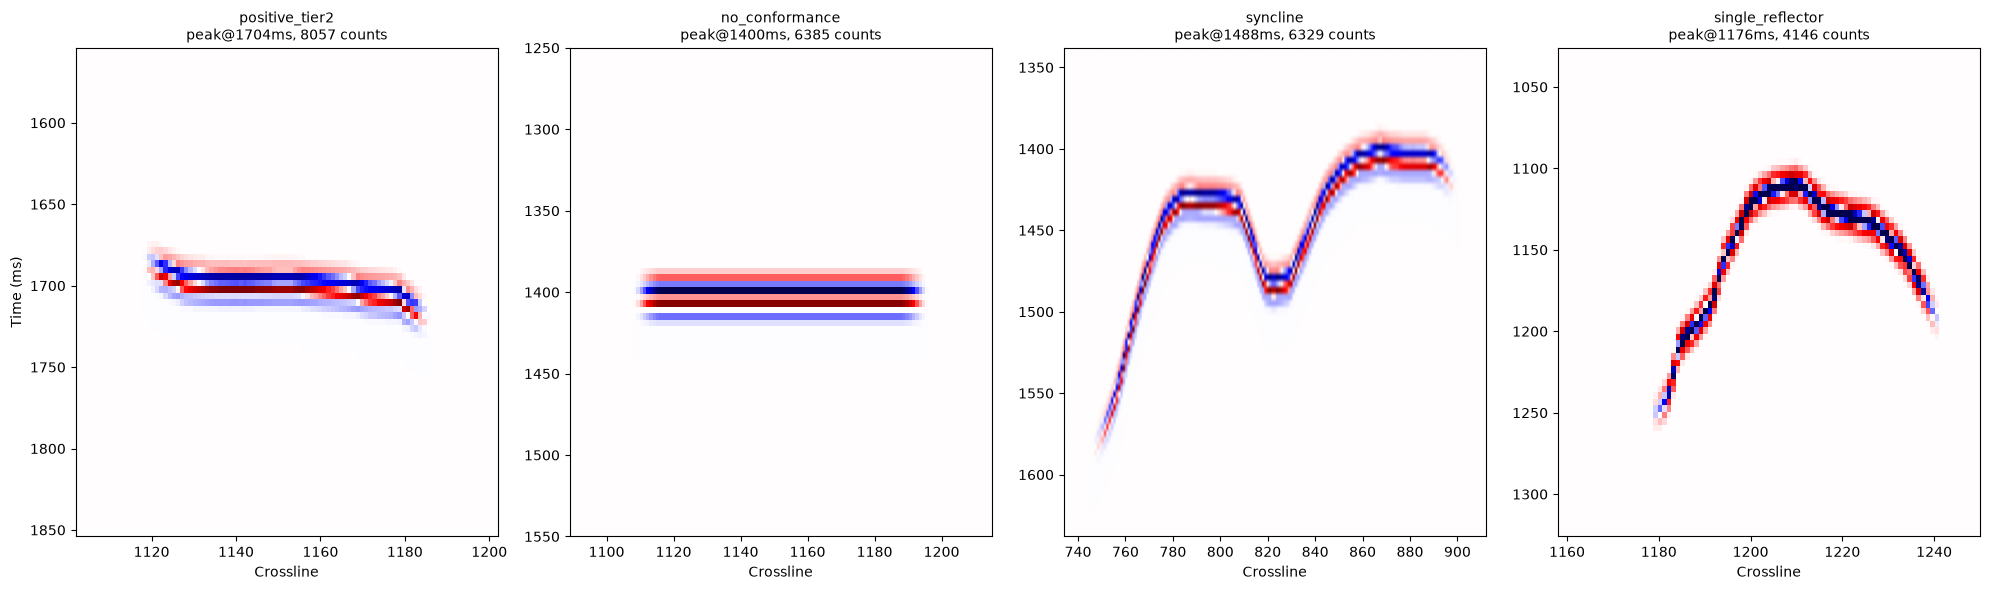

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, (name, (sc_sub, sc_inj, sc_il_ax, sc_xl_ax, sc_t_ax, il_c, xl_c)) in zip(axes, scenario_results.items()):
    il_idx = np.argmin(np.abs(sc_il_ax - il_c))
    diff = sc_inj[il_idx] - sc_sub[il_idx]
    peak_t_idx = np.unravel_index(np.nanargmax(np.abs(diff)), diff.shape)[1]
    peak_time = sc_t_ax[peak_t_idx]
    vmax = np.nanmax(np.abs(diff))

    im = ax.imshow(diff.T, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                    extent=[sc_xl_ax[0], sc_xl_ax[-1], sc_t_ax[-1], sc_t_ax[0]])
    ax.set_ylim(peak_time + 150, peak_time - 150)
    ax.set_title(f'{name}\npeak@{peak_time:.0f}ms, {vmax:.0f} counts', fontsize=10)
    ax.set_xlabel('Crossline')
axes[0].set_ylabel('Time (ms)')
plt.tight_layout()
plt.savefig('figures/f3_scenario_diffs.png', dpi=150)
plt.show()

### Reading the four scenarios

- `positive_tier2`: a conformant doublet following gentle real dip, exactly as expected.
- `no_conformance`: a dead-flat line at exactly 1400ms, cutting straight across the naturally dipping reflections around it - visually artificial in a way the others aren't, precisely because it's *not* geologically consistent with anything nearby.
- `syncline`: follows the real V-shaped structural low almost exactly (dips into the trough around crossline 820, rises on both sides) - fully conformant to real geology, just sitting in the wrong structural position to be a valid trap.
- `single_reflector`: a single connected event, visually similar to the positive at a glance - which is the point. Amplitude/polarity alone won't distinguish it from a genuine wedge; that's what makes it a hard negative rather than an easy one.

Stage 2 (diversity) and stage 3 (hard negatives) both work end-to-end on real data now. Next: the actual dataset export - patch + label (with footprint mask) files, generated in bulk across many randomised scenarios, with spatial train/test partitioning so evaluation locations were never seen during generation of the training set.

## Dataset Export: Patch + Label Files

The last piece: turn the scenario samplers into an actual on-disk dataset - fixed-size 3D patches (amplitude + envelope + instantaneous phase, per the earlier decision to support localization) plus a labels table, split spatially by inline range so test-set locations are never used to generate training examples.

`src/dhi_pipeline/attributes.py` ports the Hilbert-transform envelope/phase functions from notebook 02's facies pipeline (Roden & Chen's paper, cited at the top of this notebook, specifically flags phase/frequency as relevant for DHI detection). `src/dhi_pipeline/dataset.py` does the patch extraction, injection, attribute computation, and footprint-mask generation, and writes one `.npz` per example plus a combined `labels.parquet`.

### Patch size vs footprint size

First attempt used a 100x100-trace patch. Footprint radius samples up to 80 traces, so for the largest footprints the mask covered ~93% of the patch - almost no surrounding background context, not a useful training example (the point of the mask is to localize the anomaly *within* a scene, not fill it). Bumped to 160x160, which brings mask coverage down to a much more reasonable range (roughly 15-45% depending on the randomly sampled footprint radius) leaving clear surrounding context, while still fitting within the survey bounds for most (not all - see below) candidate locations.

### Train/test split and a real limitation

Split by inline range - train uses inline 100-400, test uses inline 480-670, leaving a gap for footprint radius so train and test patches shouldn't overlap. Worth being upfront about a real limitation this surfaced: F3's structural highs are concentrated at lower inlines, so the test zone only has 2 candidate highs to begin with, and one of those (inline 660, crossline 1210) sits close enough to the survey's crossline boundary (max 1250) that a 160-wide patch gets clipped there - skipped rather than padded, per the design. That leaves effectively one reliable positive-test location for this small a demo. Not a pipeline bug (the skip-on-edge-clip logic is doing exactly what it should), but a real scale limitation - a production run would want multiple horizons for a bigger candidate pool, not just H1.

### Checking structural-high/low distribution before choosing the train/test split

The original split (`train=(100,400)`, `test=(480,670)`) was picked without checking how the real `structural_highs`/`structural_lows` are actually distributed across the survey - it turned out badly lopsided (train got 12 of the 18 real highs, test only 2). Checking the actual inline positions before picking boundaries:

In [28]:
print('structural highs by inline:', sorted(structural_highs['inline'].tolist()))
print('structural lows by inline: ', sorted(structural_lows['inline'].tolist()))
print()

def count_in_range(df, lo, hi):
    return len(df[df.inline.between(lo, hi)])

for label, (train_range, test_range) in {
    'old split (100,400)/(480,670)': ((100, 400), (480, 670)),
    'new split (100,280)/(320,750)': ((100, 280), (320, 750)),
}.items():
    th = count_in_range(structural_highs, *train_range)
    eh = count_in_range(structural_highs, *test_range)
    tl = count_in_range(structural_lows, *train_range)
    el = count_in_range(structural_lows, *test_range)
    print(f'{label}: train highs={th} lows={tl}  |  test highs={eh} lows={el}')

structural highs by inline: [147.0, 153.0, 157.0, 180.0, 191.0, 194.0, 247.0, 251.0, 310.0, 349.0, 371.0, 385.0, 403.0, 420.0, 433.0, 522.0, 660.0, 688.0]
structural lows by inline:  [182.0, 206.0, 206.0, 213.0, 280.0, 282.0, 293.0, 339.0, 390.0, 397.0, 398.0, 401.0, 454.0, 501.0, 532.0, 549.0, 599.0, 631.0, 648.0, 667.0]

old split (100,400)/(480,670): train highs=12 lows=11  |  test highs=2 lows=7
new split (100,280)/(320,750): train highs=8 lows=5  |  test highs=9 lows=13


In [29]:
from src.dhi_pipeline.dataset import build_dataset

labels = build_dataset(
    output_dir='../data/dataset', segy_path=SEGY_PATH, iline_map=iline_map, inlines=inlines, xlines=xlines,
    horizon=horizon, dt_ms=dt_ms, velocity_mps=velocity, freq_hz=dominant_freq,
    # rebalanced from (100,400)/(480,670) - see the structural-high/low distribution check above
    # for how this was found: structural highs on H1 cluster heavily below inline ~430
    # (15 of 18 highs sit between 147-433), so that split gave train 12 highs vs test only 2.
    # Splitting around inline 300 instead, with a buffer gap (280-320) so train/test still don't
    # share nearby background, gives train 8 highs / test 9 highs - far more balanced use of the
    # same 18 real highs (this horizon has no more than that to work with either way).
    train_inline_range=(100, 280), test_inline_range=(320, 750),
    structural_highs=structural_highs, structural_lows=structural_lows,
    n_per_tier=5, n_hard_negatives_per_kind=5, seed=1,
)

print(f'{len(labels)} examples generated')
print(labels.groupby(['split', 'is_dhi']).size())

62 examples generated
split  is_dhi
test   False     17
       True      17
train  False     14
       True      14
dtype: int64


### Round-trip check

Loading two saved examples back from disk (one positive, one hard negative) and plotting the amplitude channel through the patch centre alongside the footprint mask, to confirm what's on disk actually matches what was generated - not just trusting the in-memory return value.

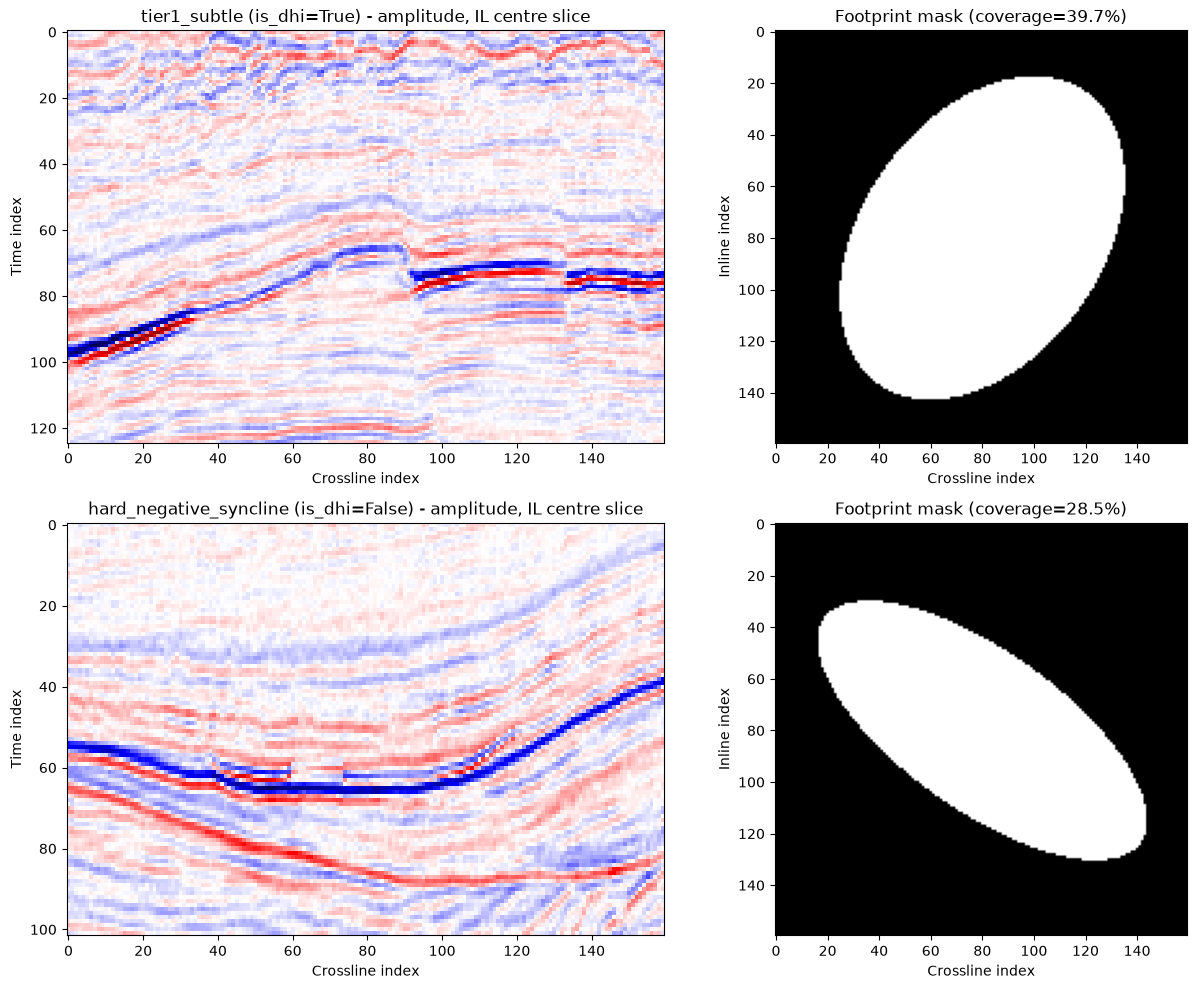

In [30]:
train_negatives = labels[(labels.split == 'train') & (~labels.is_dhi)]
# prefer syncline over no_conformance for this comparison - it's the more realistic hard negative
# (fully conformant to real structure, just sitting in the wrong structural position), whereas
# no_conformance's dead-flat shape is arguably too obviously synthetic to be a genuinely hard case
preferred_order = ['hard_negative_syncline', 'hard_negative_single_reflector', 'hard_negative_no_conformance']
hard_negative_row = next(
    train_negatives[train_negatives.kind == kind].iloc[0]
    for kind in preferred_order if (train_negatives.kind == kind).any()
)

example_rows = [
    labels[(labels.split == 'train') & (labels.is_dhi)].iloc[0],
    hard_negative_row,
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row_idx, row in enumerate(example_rows):
    data = np.load(f'../data/dataset/patches/{row.patch_file}')
    stack, mask = data['attribute_stack'], data['mask']  # stack: (3, il, xl, t), mask: (il, xl)
    center_il_idx = stack.shape[1] // 2

    ax_amp = axes[row_idx, 0]
    vmax = np.abs(stack[0, center_il_idx]).max()
    ax_amp.imshow(stack[0, center_il_idx].T, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax)
    ax_amp.set_title(f'{row.kind} (is_dhi={row.is_dhi}) - amplitude, IL centre slice')
    ax_amp.set_xlabel('Crossline index')
    ax_amp.set_ylabel('Time index')

    ax_mask = axes[row_idx, 1]
    ax_mask.imshow(mask, cmap='gray')
    ax_mask.set_title(f'Footprint mask (coverage={mask.mean():.1%})')
    ax_mask.set_xlabel('Crossline index')
    ax_mask.set_ylabel('Inline index')

plt.tight_layout()
plt.savefig('figures/f3_dataset_examples.png', dpi=150)
plt.show()

## SEG-Y Export: Visual Review Examples

The original ask was to present these as SEG-Y, not just patch/label arrays - useful for training a model, but not something a geoscientist can actually look at and judge. `segy_export.py` writes a real F3 sub-volume per scenario (full trace headers copied from the source survey) with just that one scenario injected, so it opens in normal seismic software and everything around the injection is genuine, unmodified data.

6 examples: the 4 severity tiers plus 2 hard negatives (`syncline`, `single_reflector`) - a representative spread rather than the full set, kept small since each file is its own reviewable deliverable.

In [ ]:
import os

from src.dhi_pipeline.segy_export import export_scenario_to_segy

SEGY_EXPORT_DIR = '../data/segy_export'
os.makedirs(SEGY_EXPORT_DIR, exist_ok=True)

rng = np.random.default_rng(7)
segy_scenarios = []
for tier in ['tier1_subtle', 'tier2_approaching', 'tier3_at_tuning', 'tier4_obvious']:
    kwargs, label = sample_positive_scenario(tier, rng, structural_highs, velocity, dominant_freq)
    segy_scenarios.append((f'dhi_{tier}.sgy', kwargs, label))
for kind in ['syncline', 'single_reflector']:
    kwargs, label = sample_hard_negative_scenario(kind, rng, structural_highs, structural_lows, velocity, dominant_freq)
    segy_scenarios.append((f'dhi_hard_negative_{kind}.sgy', kwargs, label))

with segyio.open(SEGY_PATH, ignore_geometry=True) as f:
    for fname, kwargs, label in segy_scenarios:
        out_path = f'{SEGY_EXPORT_DIR}/{fname}'
        result = export_scenario_to_segy(kwargs, label, f, iline_map, inlines, xlines, horizon, out_path)
        status = 'OK' if result else 'SKIPPED (off survey edge)'
        print(f'{fname}: {status}  (il={kwargs["il_center"]:.0f}, xl={kwargs["xl_center"]:.0f}, kind={label["kind"]})')

dhi_tier1_subtle.sgy: OK  (il=310, xl=1152, kind=tier1_subtle)
dhi_tier2_approaching.sgy: OK  (il=349, xl=890, kind=tier2_approaching)
dhi_tier3_at_tuning.sgy: OK  (il=385, xl=868, kind=tier3_at_tuning)
dhi_tier4_obvious.sgy: OK  (il=371, xl=837, kind=tier4_obvious)
dhi_hard_negative_syncline.sgy: OK  (il=398, xl=1094, kind=hard_negative_syncline)
dhi_hard_negative_single_reflector.sgy: OK  (il=403, xl=786, kind=hard_negative_single_reflector)

## Summary

The full pipeline, start to finish:

1. **Calibration**: dominant frequency, velocity, and tuning thickness measured from a real, verified-clean background patch - not assumed.
2. **Severity tiers**: thickness/amplitude grounded in petrophysics (Nanda's water/gas-sand contrast) and the wedge model's own empirically-measured tuning peak (7.07m, not the textbook 9.07m estimate - a real, wavelet-dependent gap this pipeline actually produces).
3. **Amplitude calibration**: dimensionless reflection coefficients converted to this dataset's real counts, anchored to the background patch's RMS amplitude - without this the whole pipeline is invisible against real data, not just "subtle."
4. **Structural conformance**: reservoir top follows real horizon surfaces (auto-discovered structural highs across the whole survey), not a synthetic flat/parametric shape.
5. **Diversity + hard negatives**: continuous per-tier parameter sampling, randomised footprint geometry, and three physically-motivated non-DHI look-alikes (flat/no-conformance, syncline, single-reflector) - so a detector has to learn the actual physics, not a shortcut.
6. **Export**: fixed-size multi-attribute patches (amplitude, envelope, instantaneous phase) with footprint masks and spatially-partitioned train/test labels, ready to hand to a model.

This notebook, `src/dhi_pipeline/`, and `utils/seismic_io.py` are the AI-assisted data-generation side of the project, deliberately kept in this separate repo from the IRP repo where the detection model itself will be built independently.